In [1]:
from plots_utils import *
import pandas as pd

In [3]:
!mkdir out_naivememory

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


# naive memory from oas

Running model: AbROBERTa_NAIVE_MEMORY_OAS
La cartella 'img' esiste già.
                                          sequence_heavy locus_heavy  \
0      ACTTTCTGAGAGTCCTGGACCTCCTGTGCAAGAACATGAGACATCT...           H   
1      GGGGGCTTTCTGAGAGTCATGGACCTCCTGTGCAAGAACATGAAGC...           H   
2      GAGCTCTGGGAGAGGAGCCCAGCACTAGAAGTCGGCGGTGTTTCCA...           H   
3      AGGTCCAACTCATAAGGGAAAAGCTTTCTGAGAGTCATGGATCGCA...           H   
4      CGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATC...           H   
...                                                  ...         ...   
99995  AGCTCTGAGAGAGGAGCCTTAGCCCTGGATTCCAAGGCCTATCCAC...           H   
99996  TGGGGAGCTCTGGGAGAGGAGCCCCAGGCCCGGGATTCCCAGGTGT...           H   
99997  AGCTCTGGGAGAGGAGCCCCAGCCTTGGGATTCCCAAGTGTTTTCA...           H   
99998  GCTTCCAGTCTCAACCAGCTTTAATTTTTCGTATCTGGGGAGGGTC...           H   
99999  TGGGGACTCCTGTGCCCCACCATGGACACACTTTGCTCCACGCTCC...           H   

        v_call_heavy                           sequence_alignme

/home/rodelc/anaconda3/envs/aa_ss_tokenizer_2.0/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP coordinates saved to ./out_naivememory//UMAP_AbROBERTa_NAIVE_MEMORY_OAS PCA embeddings.csv
IMG saved to img/UMAP_AbROBERTa_NAIVE_MEMORY_OAS PCA embeddings.png


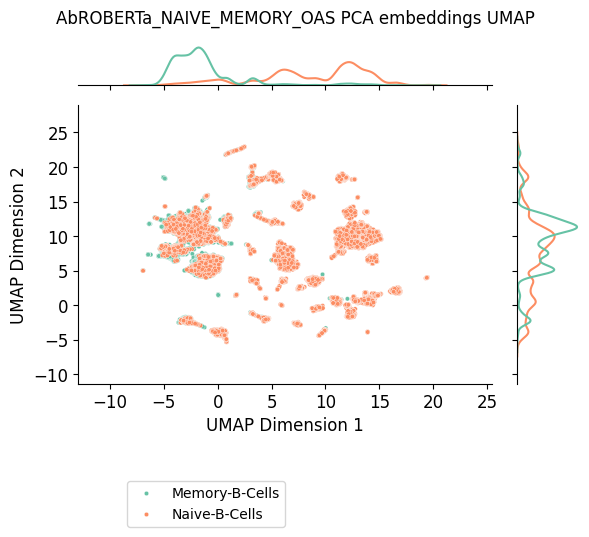

Computing PCA coordinates...
PCA coordinates saved to ./out_naivememory//PCA_AbROBERTa_NAIVE_MEMORY_OAS PCA embeddings.csv


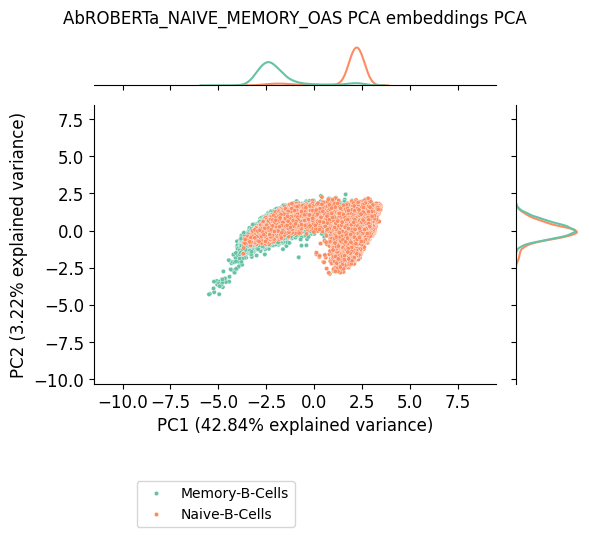

IMG saved to img/PCA_AbROBERTa_NAIVE_MEMORY_OAS PCA embeddings.png


In [4]:
import os
from evaluate_mlm import main
import pandas as pd


MODEL_PATH = "mogam-ai/Ab-RoBERTa"

#Percorso alla cartella dei file .txt
TXT_DIR = '../50knaive_50kmemory_oas_paired_randomly_selected.csv'


# Output directory
REDUCTION_OUTPUT_PATH = './out_naivememory/'

filepath = TXT_DIR
filename ="NAIVE_MEMORY_OAS"

# Legge il file come CSV senza intestazione, ma con separatore ','
df = pd.read_csv(filepath, header=0)
df = df.rename(columns={'sequence_alignment_aa_heavy': 'sequence'})
df = (
df.groupby('sequence', as_index=False)                # raggruppa per sequenza
.filter(lambda g: len(g.drop_duplicates()) == 1)    # scarta i gruppi "misti"
.drop_duplicates(subset='sequence')                 # rimuove l'unico duplicato rimasto
)


# Ora puoi passare il dataframe direttamente, oppure salvarlo in memoria come CSV-like string
# oppure modificare la funzione `main()` per accettare anche DataFrame in input
# Qui lo salviamo temporaneamente in memoria come oggetto CSV per compatibilità
tmp_csv_path = '/tmp/tmp_data.csv'
df.to_csv(tmp_csv_path, index=False)

model_name = 'AbROBERTa_' + filename.replace('.csv', '').upper()
embedding_file = f"./{model_name}_embeddings.pkl"
plot_title = model_name + ' PCA embeddings'
hue_class = 'BType'

print(f"Running model: {model_name}")

main(model_name, MODEL_PATH, tmp_csv_path, embedding_file, plot_title, hue_class,
    REDUCTION_OUTPUT_PATH, umap=True, pca=True)

#Embeddings saved to ./H3BERTA_ADA_embeddings.pkl
#Loading UMAP coordinates from ./out_ada//UMAP_H3BERTA_ADA PCA embeddings.csv

In [5]:
!mkdir img

mkdir: cannot create directory ‘img’: File exists


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


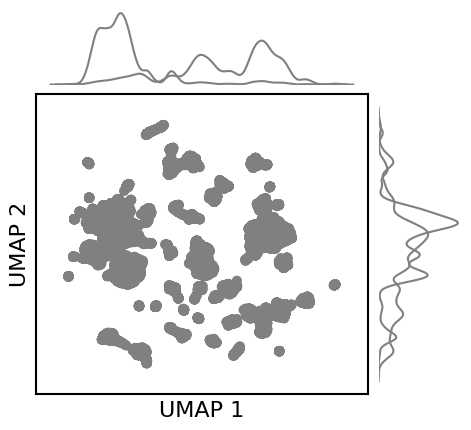

<Figure size 300x100 with 0 Axes>

In [7]:
from plots_utils import *
import pandas as pd
df = pd.read_csv("./out_naivememory/UMAP_AbROBERTa_NAIVE_MEMORY_OAS PCA embeddings.csv")
plot_umap_single_gene_INSCAPE_biggerpoints(df, gene_col= 'BType', title= 'BType', file_suffix="./img/PAPER_NAIVE_MEMORY_OAS")

# LDA

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
import pandas as pd
import re

def compute_multiple_ldas(df, embedding_col='embeddings', target_cols=['v_family', 'j_family', 'd_family'], n_components=1):
    """
    Applies LDA to embeddings using multiple target columns.
    Adds separate LDA projections to the dataframe for each target.

    Returns:
    - df with new columns: lda1_{target}, lda2_{target}, ...
    """

    def clean_and_convert_embedding(s):
        if isinstance(s, np.ndarray):
            return s
        if isinstance(s, str):
            s_clean = re.sub(r'\s+', ' ', s.strip())
            s_clean = re.sub(r'(?<=\d)-', ' -', s_clean)
            s_clean = re.sub(r'(?<=[0-9]) (?=[-+]?\d)', ',', s_clean)
            return np.fromstring(s_clean.strip("[]"), sep=",")
        return np.array(s)

    # Clean embeddings
    
    df[embedding_col] = df[embedding_col].apply(clean_and_convert_embedding)
    embedding_matrix = np.vstack(df[embedding_col].values)

    for target_col in target_cols:
        labels = df[target_col] # ensure categorical strings
        lda = LinearDiscriminantAnalysis(n_components=n_components)
        lda_result = lda.fit_transform(embedding_matrix, labels)
        for i in range(n_components):
            df[f'lda{i+1}_{target_col[0]}'] = lda_result[:, i]

    return df


def plot_lda_overview(df, file_suffix="output"):
    fig = plt.figure(figsize=(20, 5))
    outer = gridspec.GridSpec(1, 4, wspace=0.15)

    genes = ['v_family', 'j_family', 'd_family']
    titles = ['V Gene', 'J Gene', 'D Gene']

    def plot_joint(fig, gs, x, y, category_col, legend_title, show_ylabel):
        ax_joint = fig.add_subplot(gs[1, 0])
        ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_joint)
        ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_joint)

        handles, labels = [], []

        for cat in df[category_col].dropna().unique():
            sub_df = df[df[category_col] == cat]
            style = custom_palette.get(cat, {'color': 'grey', 'size': 10, 'marker': 'o'})
            sc = ax_joint.scatter(sub_df[x], sub_df[y],
                                  c=[style['color']] * len(sub_df),
                                s=style['size'], marker=style['marker'],
                                alpha=0.3, label=cat)
            handles.append(sc)
            labels.append(cat)

            sns.kdeplot(sub_df[x], ax=ax_marg_x, color=style['color'],
                        fill=False, linewidth=2, common_norm=False)
            sns.kdeplot(sub_df[y], ax=ax_marg_y, color=style['color'],
                        fill=False, linewidth=2, common_norm=False, vertical=True)

        ax_joint.set_xticks([])
        ax_joint.set_yticks([])
        ax_joint.set_xlabel("LDA 1", fontsize=16)
        ax_joint.set_ylabel("LDA 2" if show_ylabel else "", fontsize=16)
        ax_marg_x.axis('off')
        ax_marg_y.axis('off')

        # ax_joint.legend(handles, labels, title=legend_title, loc='upper center',
        #                 bbox_to_anchor=(0.5, -0.1), fontsize=14, title_fontsize=16,
        #                 ncol=3, frameon=False, markerscale=3)
        ax_joint.legend(handles, labels, title='', loc='best', fontsize=10, title_fontsize=10,
                frameon=False, markerscale=3, ncol=2,
                columnspacing=0.0, handletextpad=0.0, borderpad=0.0)
        # >>> Qui aumenta lo spessore dei bordi
        for ax in [ax_joint, ax_marg_x, ax_marg_y]:
            for spine in ax.spines.values():
                spine.set_linewidth(1.5)

    # Plot each LDA projection (v, j, d)
    for i, (gene, title) in enumerate(zip(genes, titles)):
        inner = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[i],
                                                width_ratios=[4, 1], height_ratios=[1, 4],
                                                wspace=0.0, hspace=0.0)
        plot_joint(fig, inner,
                f'lda1_{gene[0]}', f'lda2_{gene[0]}',
                category_col=gene,
                legend_title='',
                show_ylabel=(i == 0))

    plt.tight_layout()
    plt.subplots_adjust(left=0.03, right=0.80, top=0.95, bottom=0.1)
    plt.savefig(f"{file_suffix}_lda_overview.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"{file_suffix}_lda_overview.svg", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

In [9]:
compute_multiple_ldas(df, target_cols= ['BType'])

,sequence_heavy,locus_heavy,v_call_heavy,sequence_alignment_heavy,sequence,germline_alignment_aa_heavy,cdr3_aa_heavy,sequence_light,locus_light,v_call_light,...,germline_alignment_aa_light,cdr3_aa_light,sequence_alignment_heavy_sep_light,BType,Disease,Species,embeddings,umap1,umap2,lda1_B
0,ACTTTCTGAGAGTCCTGGACCTCCTGTGCAAGAACATGAGACATCT...,H,IGHV4-59*02,CAGGTGCACCTGCAGGAGTCGGGCCCAGGACTGGTGAGGCCTTCGG...,QVHLQESGPGLVRPSETLSLTCTVSGGSVSSSYWSWIRQSPGKGLE...,QVQLQESGPGLVKPSETLSLTCTVSGGSVSSYYWSWIRQPPGKGLE...,ANSGFYEKFDY,AGAGCTCTGGAGAAGAGCTGCTCAGTTAGGACCCAGAGGGAACCAT...,K,IGKV3-20*01,...,EIVLTQSPGTLSLSPGERATLSCRASQSVSSSYLAWYQQKPGQAPR...,QQYGDSPLT,QVHLQESGPGLVRPSETLSLTCTVSGGSVSSSYWSWIRQSPGKGLE...,Memory,CMV,human,"[0.414561898, -0.0661052242, 0.395893812, 0.20...",-1.724528,4.837978,-2.203040
1,GGGGGCTTTCTGAGAGTCATGGACCTCCTGTGCAAGAACATGAAGC...,H,IGHV4-38-2*02,CAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTGGTGAAGCCTTCGG...,QVQLQESGPGLVKPSETLSLTCAVSGFSLSSGFYWGWMRQPPGKGL...,QVQLQESGPGLVKPSETLSLTCTVSGYSISSGYYWGWIRQPPGKGL...,ARERGGVIAATCMDV,GGCTGGGGTCTCAGGAGGCAGCACTCTCGGGACGTCTCCACCATGG...,L,IGLV2-11*01,...,QSALTQPRSVSGSPGQSVTISCTGTSSDVGGYNYVSWYQQHPGKAP...,CSFAGRYTFRV,QVQLQESGPGLVKPSETLSLTCAVSGFSLSSGFYWGWMRQPPGKGL...,Memory,NaN,human,"[0.459726065, -0.00918169226, 0.345905781, 0.0...",-1.023675,6.723098,-1.673172
2,GAGCTCTGGGAGAGGAGCCCAGCACTAGAAGTCGGCGGTGTTTCCA...,H,IGHV3-30*18,CAGGTGCAGATGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,QVQMVESGGGVVQPGRSLRLSCAASGFIFSSYGMHWVRQAPGKGLE...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,AKDRYGSGSHFAY,AGGAGTCAGACCCAGTCAGGACACAGCATGGACATGAGGGTCCCCG...,K,IGKV1-5*03,...,DIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKL...,QQYDSYSLT,QVQMVESGGGVVQPGRSLRLSCAASGFIFSSYGMHWVRQAPGKGLE...,Memory,NaN,human,"[0.353019953, 0.0543038808, 0.482492894, 0.229...",-2.632335,10.633021,-1.623543
3,AGGTCCAACTCATAAGGGAAAAGCTTTCTGAGAGTCATGGATCGCA...,H,IGHV4-39*01,CAGGTGCAGCTGCGACAGGCGGGCCCAGGACTGGCGAAGCCTTCGG...,QVQLRQAGPGLAKPSETLSLTCTVSGGSISSSVHYWGWVRQTPGKG...,QLQLQESGPGLVKPSETLSLTCTVSGGSISSSSYYWGWIRQPPGKG...,ARHGPLWFGVQNWFDS,TGAGCGCAGAAGGCAGGACTCGGGACAATCTTCATCATGACCTGCT...,L,IGLV1-51*02,...,QSVLTQPPSVSAAPGQKVTISCSGSSSNIGNNYVSWYQQLPGTAPK...,GTWDNSLGIGSWV,QVQLRQAGPGLAKPSETLSLTCTVSGGSISSSVHYWGWVRQTPGKG...,Memory,SARS-COV-2,human,"[0.262967438, 0.0153913386, 0.122813061, 0.064...",-1.543519,4.974215,-2.326724
4,CGAGCCCAGCACTGGAAGTCGCCGGTGTTTCCATTCGGTGATCATC...,H,IGHV3-30-3*01,CAGGTGCAGCTGGTGGAGTCTGGGGGAGGCGTGGTCCAGCCTGGGA...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLE...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLE...,ARDPSTYSGYDRYFDY,GGGGAGGAACTGCTCAGTTAGGACCCAGAGGGAACCATGGAAGCCC...,K,IGKV3-11*01,...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,QQRSNWPT,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLE...,Memory,SARS-COV-2,human,"[0.166617304, -0.299851954, 0.69885695, -0.082...",11.656895,10.825780,2.075113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,AGCTCTGAGAGAGGAGCCTTAGCCCTGGATTCCAAGGCCTATCCAC...,H,IGHV3-21*01,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCCTGGTCAAGCCTGGGG...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,ARDPPGYKGFDY,AGAGCTCTGGGGAGGAACTGCTCAGTTAGGACCCAGACGGAACCAT...,K,IGKV3-15*01,...,EIVMTQSPATLSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRL...,QQYNNWPPSLT,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,Naive,SARS-COV-2,human,"[0.110297598, -0.288695991, 0.531934917, -0.01...",11.321324,10.004307,2.010883
99996,TGGGGAGCTCTGGGAGAGGAGCCCCAGGCCCGGGATTCCCAGGTGT...,H,IGHV3-64D*06,GAGGTGCAGCTGGTGGAGTCTGGGGGAGGCTTGGTCCAGCCTGGGG...,EVQLVESGGGLVQPGGSLRLSCSASGFTFSSYAMHWVRQAPGKGLE...,EVQLVESGGGLVQPGGSLRLSCSASGFTFSSYAMHWVRQAPGKGLE...,VKDPAGITPGY,TGGGGAGGAGTCAGTCTCAGTCAGGACACAGCATGGACATGAGGGT...,K,IGKV1-39*01,...,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKL...,QQSYSTPWT,EVQLVESGGGLVQPGGSLRLSCSASGFTFSSYAMHWVRQAPGKGLE...,Naive,CMV,human,"[0.0809135064, -0.411086887, 0.49984926, -0.03...",4.469501,0.977890,2.031625
99997,AGCTCTGGGAGAGGAGCCCCAGCCTTGGGATTCC

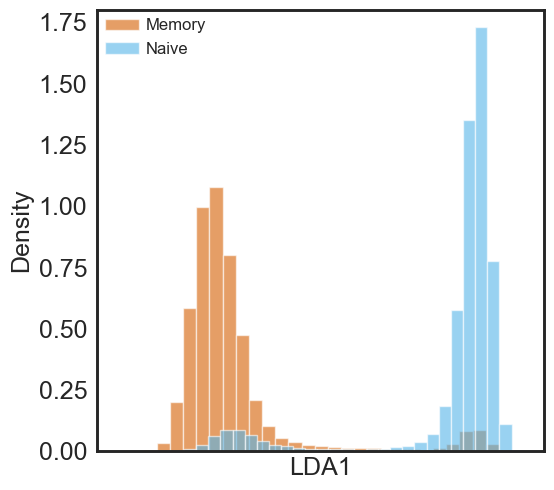

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.gridspec as gridspec

# Applica stile coerente
sns.set_style("white")
plt.rcParams.update({
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'axes.linewidth': 1.5,
})

# Definisci colori custom
custom_palette = {
    "Memory": {'color': mcolors.to_rgba("#D55E00", alpha=0.9), 'size': 3, 'marker': 'o'},
    "Naive": {'color': mcolors.to_rgba("#56B4E9", alpha=0.9), 'size': 3, 'marker': 'o'}
}

# Crea figura
fig = plt.figure(figsize=(5.5, 5))

gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                        wspace=0.05, hspace=0.05)

for label in df['BType'].unique():
    subset = df[df['BType'] == label]
    color = custom_palette.get(label, {'color': 'grey'})['color']  # default: grey
    plt.hist(
        subset['lda1_B'],
        bins=30,
        alpha=0.6,
        label=label,
        density=True,
        color=color
    )

# Etichette assi
plt.xlabel("LDA1", fontsize=18)
plt.ylabel("Density", fontsize=18)

# Rimuove ticks
ax = plt.gca()
ax.tick_params(axis='y', which='major', labelsize=18)
ax.set_xticks([])
ax.set_ylim(top=1.8) 

# Bordi più spessi
for spine in ax.spines.values():
    spine.set_linewidth(2.1)

# Legenda stile INSCAPE
plt.legend(frameon=False, ncol=1, columnspacing=0.0, handletextpad=0.4, borderpad=0.0)

# Layout compatto
plt.tight_layout()

# Salva la figura
fig.savefig("PAPER_AbROBERTA_lda_histogram_BType.png", dpi=300, bbox_inches='tight')
fig.savefig("PAPER_AbROBERTA_lda_histogram_BType.svg", dpi=300, bbox_inches='tight')

# Mostra a schermo
plt.show()
